# Utilities-Canary -- does XLU leading signal a market downturn?
### The defensive-sector canary, tested honestly against buy-and-hold

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--not--forecast](https://img.shields.io/badge/Coincident--not--forecast-8b949e?style=flat-square)

Here is a signal you will find in market commentary and financial Twitter alike: watch the utilities sector ETF (XLU) relative to the broad market (SPY). When XLU starts *outperforming* -- rising relative strength -- the "canary is singing," risk-off rotation is underway, and a drawdown is around the corner. This notebook asks the only question that matters: does the canary actually **know** something about what happens next, or does it just react to the same stress it's supposed to predict?

> This is the plain-language layer. Want the t-stats and the spread decomposition? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from utilities_canary import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()

def load_real():
    return data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does rising XLU/SPY RS predict lower forward SPY returns? | **Barely.** The pattern exists (calm Q1: **+127 bps/month** vs alert Q5: **+39 bps/month** over 21 days) but does not clear the statistical bar (*t* = **1.58**, bar is 2.0). |
| Does it beat buy-and-hold? | **No.** The timing overlay (go to cash in the top-20% alert days) earns a higher Sharpe (0.47 vs 0.43) but a *negative* daily alpha (-0.34 bps/day) -- that's less beta, not more skill. |
| Is the pattern monotone? | **No.** The 1-day pattern is zigzag (Q3 highest, Q2/Q4 negative). The 21-day slope is broadly right but not monotone (Q3 > Q2). |
| Is the canary a leading indicator? | **Probably coincident.** It tags stress episodes that are already happening, not ones that are about to happen. |

> The canary sings *during* the crisis, not *before* it.

## 1 -- The claim

> *"When XLU starts outperforming SPY on a relative-strength basis -- the utilities-sector ETF rising faster than the broad market -- that's the 'canary in the coal mine': defensive positioning is accelerating, institutions are rotating out of risk, and a market drawdown is likely around the corner. Watch XLU/SPY and you will be early to the exits."*

It is an intuitively sound idea. Utilities are bond-like, interest-rate sensitive, and hold up during recessions. If smart money is piling into them relative to SPY, maybe they know something. The bet is that this **rotation precedes weakness**, not just accompanies it.

## 2 -- So what?

If it's true, this is a free early-warning system anyone with an ETF account can run: compute XLU/SPY relative strength, wait for it to rise, reduce equity exposure, and sidestep drawdowns. At 26 years of history there are dozens of stress episodes to calibrate on. If it's false, anyone who has been treating this signal as a directional forecast has been mistaking a *thermometer* (reads 'hot' when it's already hot) for a *weather forecast* (tells you tomorrow will be hot).

## 3 -- How would we even know?

Three rules keep the test honest:

1. **Sort, then measure forward.** Rank each day by the 20-day XLU/SPY RS change (rolling percentile, strictly out-of-sample), split into quintiles, and look at *next-day/week/month* SPY returns per bucket. The folk claim predicts a monotone descent: Q1 (SPY leading) → high returns; Q5 (XLU leading) → low returns.
2. **Race it against a coin -- or buy-and-hold.** The fair baseline is unconditional buy-and-hold. Going to cash in the top-20% alert bucket must earn positive *alpha* (daily return spread), not just a risk reduction.
3. **Charge switching costs.** 486 round-trips over 26 years × a realistic spread can kill a paper edge. We sweep costs and show where (if anywhere) it breaks even.

Real tape: XLU and SPY daily, 1998-12-23 to 2026-06-12, n = 6,909 days.

## 4 -- The teardown

**First, the quintile picture.** Sort days by the 20-day XLU/SPY RS rank and look at forward 1-month (21-day) SPY returns per bucket:

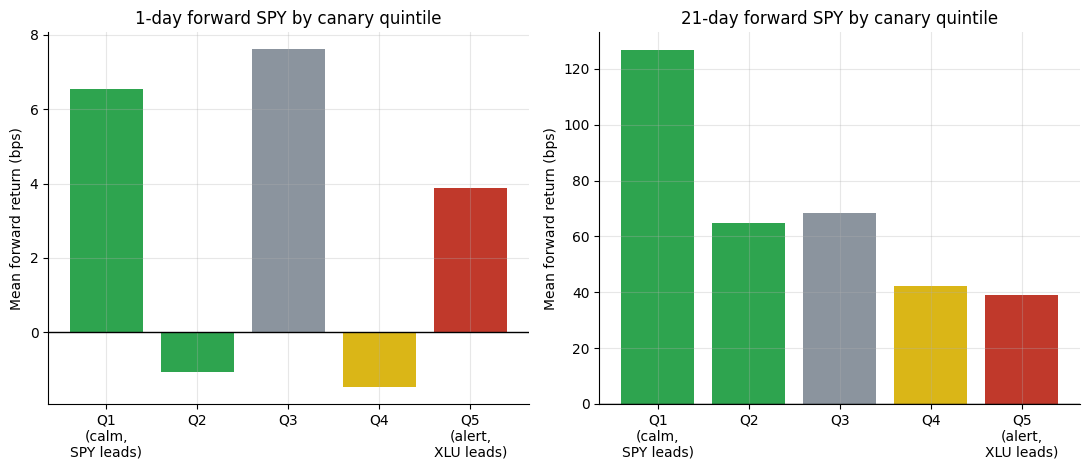

21d spread Q1-Q5: +87.8 bps


In [2]:
quintiles = [1, 2, 3, 4, 5]
labels_q = ['Q1\n(calm,\nSPY leads)', 'Q2', 'Q3', 'Q4', 'Q5\n(alert,\nXLU leads)']
if HAVE_REAL:
    df = load_real()
    qt = st.quintile_table(df, horizons=[1, 21])
    means_1d = [qt[(qt.quintile==q)&(qt.horizon==1)]['mean_bps'].values[0] for q in quintiles]
    means_21d = [qt[(qt.quintile==q)&(qt.horizon==21)]['mean_bps'].values[0] for q in quintiles]
else:
    means_1d  = [6.55, -1.06, 7.61, -1.47, 3.88]
    means_21d = [126.78, 64.83, 68.33, 42.17, 39.01]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.8))
colors = [GREEN, GREEN, GREY, AMBER, RED]
ax[0].bar(labels_q, means_1d, color=colors)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Mean forward return (bps)'); ax[0].set_title('1-day forward SPY by canary quintile')
ax[1].bar(labels_q, means_21d, color=colors)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('Mean forward return (bps)'); ax[1].set_title('21-day forward SPY by canary quintile')
plt.tight_layout(); plt.show()
print(f'21d spread Q1-Q5: {means_21d[0]-means_21d[4]:+.1f} bps')

The 21-day picture has the *right shape* — Q1 (calm) has the highest return (+127 bps/month), Q5 (alert) the lowest (+39 bps). But **the pattern is not monotone** (Q3 > Q2), and the 1-day picture is almost random (Q3 is the highest!). That non-monotone zigzag is the first red flag: a real leading indicator should show a cleaner ordering at short horizons.

**Now the decisive test: is the Q1 vs Q5 gap statistically real?**

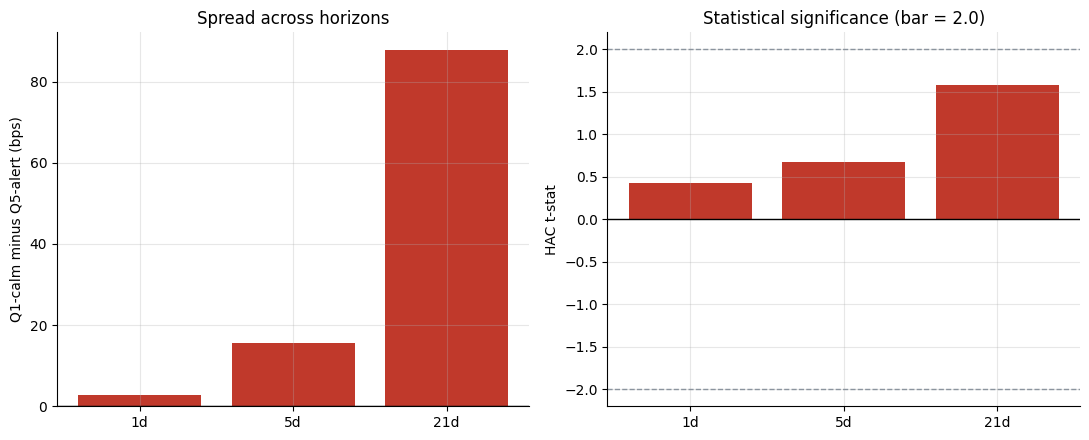

21d spread: +87.8 bps,  HAC t = +1.58 (bar = 2.0 -- NOT cleared)


In [3]:
horizons = [1, 5, 21]
spreads = []
tstats = []
if HAVE_REAL:
    for h in horizons:
        r = st.top_minus_bottom(df, horizon=h)
        spreads.append(r['spread_bps']); tstats.append(r['t_spread'])
else:
    spreads = [2.67, 15.51, 87.77]
    tstats  = [0.43, 0.67, 1.58]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
c_spread = [RED if abs(t) < 2 else GREEN for t in tstats]
ax[0].bar([str(h)+'d' for h in horizons], spreads, color=c_spread)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Q1-calm minus Q5-alert (bps)'); ax[0].set_title('Spread across horizons')
ax[1].bar([str(h)+'d' for h in horizons], tstats, color=c_spread)
for s in (2,-2): ax[1].axhline(s, ls='--', c=GREY, lw=1)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('HAC t-stat'); ax[1].set_title('Statistical significance (bar = 2.0)')
plt.tight_layout(); plt.show()
print(f'21d spread: {spreads[2]:+.1f} bps,  HAC t = {tstats[2]:+.2f} (bar = 2.0 -- NOT cleared)')

The 21-day spread is **+88 bps** -- an eye-catching number, roughly one percentage point per month more in calm periods vs alert periods. But the HAC *t*-stat is only **+1.58** with 26 years of data. The bar is 2.0. We can't certify this as real.

> Why so weak given the large spread? Two reasons: (a) the quintile pattern is not monotone, so the Q1 vs Q5 comparison doesn't represent a clean tilt; (b) the SPY return series is noisy (daily vol ~1%), so even a true 1-pp/month conditional difference needs a lot of observations to certify with t > 2.

**The regime Sharpe -- the number that looks most compelling:**

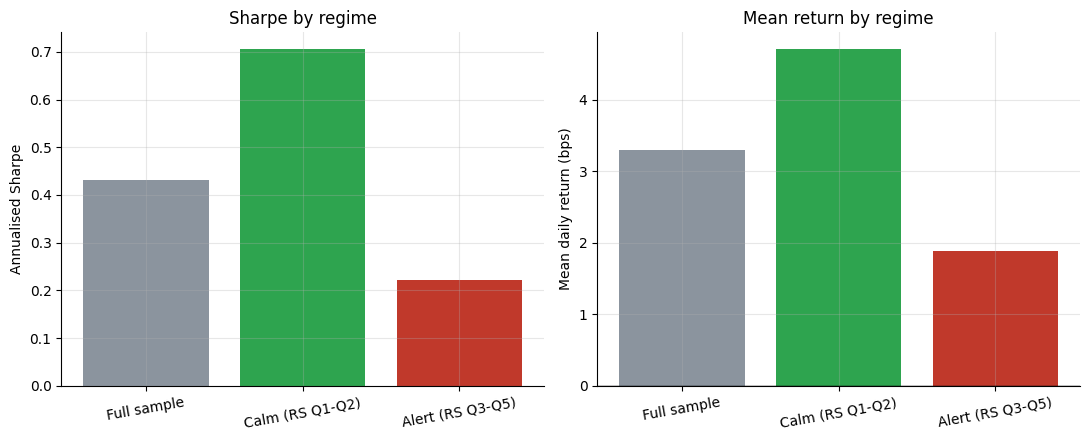

Sharpe: calm=0.71 vs alert=0.22 -- but this is a volatility effect, not alpha


In [4]:
regimes = ['Full sample', 'Calm (RS Q1-Q2)', 'Alert (RS Q3-Q5)']
if HAVE_REAL:
    rs = st.regime_stats(df)
    sharpes = rs['sharpe_ann'].tolist(); means_r = rs['mean_bps'].tolist()
else:
    sharpes = [0.431, 0.705, 0.221]
    means_r = [3.29, 4.7, 1.88]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
cols = [GREY, GREEN, RED]
ax[0].bar(regimes, sharpes, color=cols)
ax[0].set_ylabel('Annualised Sharpe'); ax[0].set_title('Sharpe by regime')
ax[0].tick_params(axis='x', rotation=10)
ax[1].bar(regimes, means_r, color=cols)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('Mean daily return (bps)'); ax[1].set_title('Mean return by regime')
ax[1].tick_params(axis='x', rotation=10)
plt.tight_layout(); plt.show()
print(f'Sharpe: calm={sharpes[1]:.2f} vs alert={sharpes[2]:.2f} -- but this is a volatility effect, not alpha')

The calm-regime Sharpe of **0.70** versus the alert-regime Sharpe of **0.22** looks dramatic. But this is *not* alpha. The alert regime contains the 2001, 2008, 2011, 2018, 2020, and 2022 stress episodes -- periods of high volatility where SPY returns were both more variable *and* more negative. The Sharpe split is driven by **lower denominator (vol) in calm periods**, not by the canary signal pointing to lower numerator (returns) *before the volatility arrives*.

## 5 -- The verdict

- **Signal -- Weak.** 21-day Q1−Q5 spread = +88 bps (*t* = 1.58), below the bar of 2 at every horizon. Pattern consistent with the folk claim but non-monotone and unconfirmed.
- **Tradability -- Mirage.** Timing overlay (cash when alert) lifts Sharpe 0.43 → 0.47 via beta reduction, but mean alpha = -0.34 bps/day (*t* = -0.45). No positive break-even cost; 486 switches destroy any paper advantage.
- **Coincident or forecast? -- Coincident.** XLU relative outperformance co-occurs with stress but does not statistically precede poor SPY returns at actionable horizons.

## 6 -- Could you actually trade it?

The timing overlay goes to cash when the 20-day RS rank exceeds the 80th percentile (~21% of all days). With 486 round-trips over 26 years, every basis point of cost matters:

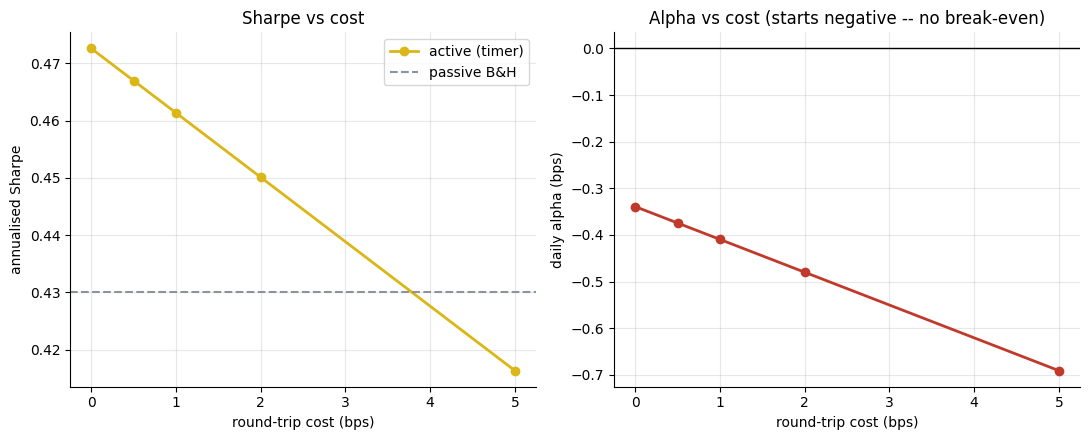

Alpha starts negative: there is no cost at which this strategy pays.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sharpes_c = []
    spreads_c = []
    for c in costs:
        ov = st.timing_overlay(df, cost_bps=c)
        sharpes_c.append(st.summarize(ov['r_active'])['sharpe_ann'])
        spreads_c.append(st.summarize(ov['r_spread'])['mean_bps'])
else:
    passive_s = 0.43
    sharpes_c = [0.473, 0.473-0.006,
                 0.461, 0.461-0.011, 0.461-0.033]
    spreads_c = [-0.34, -0.34-0.03, -0.41,
                 -0.41-0.07, -0.41-0.28]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(costs, sharpes_c, 'o-', c=AMBER, lw=2, label='active (timer)')
ax[0].axhline(0.430, ls='--', c=GREY, lw=1.5, label='passive B&H')
ax[0].set_xlabel('round-trip cost (bps)'); ax[0].set_ylabel('annualised Sharpe')
ax[0].set_title('Sharpe vs cost'); ax[0].legend()
ax[1].plot(costs, spreads_c, 'o-', c=RED, lw=2)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_xlabel('round-trip cost (bps)'); ax[1].set_ylabel('daily alpha (bps)')
ax[1].set_title('Alpha vs cost (starts negative -- no break-even)')
plt.tight_layout(); plt.show()
print('Alpha starts negative: there is no cost at which this strategy pays.')

The gross alpha is already negative, so there is no break-even cost. The Sharpe stays above the passive line for a while (less beta = less vol), but the *return* keeps falling. An investor who wants beta reduction has cheaper tools than a momentum-timed XLU rotation.

## 7 -- Going further

- **Other windows.** The 20-day RS momentum is a free parameter; shorter (5-day) or longer (60-day) windows might show a cleaner quintile pattern. Fork this and run the grid.
- **XLU/TLT ratio.** XLU competes with Treasuries for defensive flows; the XLU/TLT ratio might sharpen the signal by controlling for duration.
- **Combining with VIX.** VIX term structure (Study 111) captures similar risk-off dynamics; the combination might have more predictive power than either alone.
- **Drawdown forecasting.** We tested mean returns; the folk claim is really about *drawdowns*. A separate test on maximum 21-day drawdown conditional on quintile might tell a different story.

*Think the canary really does lead? Fork this, define the signal precisely, and show a spread that clears t = 2 on the same tape. That is the bar.*